# Критерий Хи-квадрат - как критерий Колмогорова, но для дискретных распределений  (называется Contingency)

Статья: https://github.com/avito-tech/applied_statistics/blob/main/Chi-Squared.ipynb

Например берем кубим, хотим по проверить, что $p_1 = ... = p_6 = \frac{1}{6}$

Статистика: $$\tau = n\sum_{i} \frac{\left(\frac{n_i}{n} - p_i\right)^2}{p_i}, n_i \text{ - сколько раз выпало число } i$$

В пользу альтернативы говорят большие значения статистики, то есть гипотеза правостороняя

$H_0: p_1 = ... = p_6 = \frac{1}{6}, H_1: \text{ вероятности другие}$

При $H_0: \tau \sim \Chi_{k-1}^2$, $k$ - число исходов

Условия применимости
1. Дискретное распределение 
2. $n_i >= 5$ (в каждой ячейке хотя бы 5 наблюдений)
3. Для случая frequence table 2x1 число наблюдений в каждой ячейке выше 10
4. Важно: при оценке каждого истинного параметра исходного распределения по ОМП количество степеней свободы уменьшается на 1. 

Как делать в Python:    
```python
chisquare(f_obs = frequencies_observed_corrected, f_exp = frequencies_expected, ddof = 1 )
# ddof = Delta Degrees of Freedom, сколько параметров мы оценили, а не взяли точные
```

> Идея: Можно непрерывное распределение превратить в дискретное с помощью бинов и проверять гипотезу с помощью Chi-Squared

**Решаем задачу**

> Задача: понять, правда ли, что количество посещений пользователя в месяц зависит от времени, которое он зарегистрирован в Авито 

| | 1 год | 2 года | 3 года | 4 года | 5 лет | 6 лет |
| --- | --- | --- | --- | --- | --- | --- |
| посещений <= 9 | 932299 | 680684 | 794884 | 585978 | 470660 | 397554 |
| посещений 10-19| 490658 | 519094 | 648085 | 416680 | 347016 | 315555 |
| посещений 20-29| 223166 | 347325 | 306182 | 219092 | 254512 | 237701 |
| посещений 30+| 204310 | 426824 | 277656 | 127961 | 237965 | 220446 |

$H_0$: посещения независимы 

То есть, вероятность попасть в каждую ячейку будет равна $p_i * q_j$

Осталось оценить параметры $p_i$ и $q_j$ и далее применить Contingency критерий


$$
p_1 = \frac{n_{11} + n_{21} + n_{31} + n_{41}}{n}
$$

$$
\ldots
$$

$$
p_6 = \frac{n_{16} + n_{26} + n_{36} + n_{46}}{n}
$$

$$
q_1 = \frac{n_{11} + n_{12} + n_{13} + n_{14} + n_{15} + n_{16}}{n}
$$

$$
\ldots
$$

$$
q_4 = \frac{n_{41} + n_{42} + n_{43} + n_{44} + n_{45} + n_{46}}{n},
$$

где
$$
n = \sum n_{ij}.
$$

Мы помним, что за каждый оцененный параметр число степеней свободы в распределении статистики уменьшается на 1.  
Сколько параметров мы тут оценили? На самом деле, 5 параметров для $\psi$ и 3 параметра для $\eta$
(последний параметр арифметически выводится из остальных вычитанием из единицы, поэтому его не считаем).

Итого, статистикой нашего критерия в общем случае будет

$$
\tau
= n \sum_{i=1,\,j=1}^{i=m,\,j=k}
\frac{\left(\frac{n_{ij}}{n} - q_i p_j\right)^2}{q_i p_j}
\sim \chi^2_{mk-(m-1)-(k-1)-1}
= \chi^2_{(m-1)(k-1)},
$$

где $m$ — число выборок, $k$ — число исходов в них, а $q_i$ и $p_j$ оценены, как описано выше.

Ура! Мы свели критерий независимости к тому, что мы знаем про критерии согласия.

В python:   
```python
chi2_contingency(observed=[[932299, 680684, 794884, 585978, 470660, 397554], [490658, 519094, 648085, 416680, 347016, 315555], [223166, 347325, 306182, 219092, 254512, 237701], [204310, 426824, 277656, 127961, 237965, 220446]])
```

In [2]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [30]:
# Проверим гипотезу о принадлежности выборки нормальному распределению 
# 1. C помощью критерия Колмогорова 
# 2. С помощью критерия Хи-квадрат
# Нулевая гипотеза: Нормальной распрделение с mu=0, scale=1
# Альтернативная: распределение другое

monteCarloResults = namedtuple('MonteCarloResults', ['type_one', 'ci_left', 'ci_right'])

# Используем тест Колмогорова
def run_monte_carlo_Kolmogorov(sample_size, mu, var, n_iter, alpha):
    count = 0
    for _ in range(n_iter):
        sample = stats.norm(loc=mu, scale=var).rvs(sample_size)

        pvalue = stats.kstest(sample, cdf=stats.norm().cdf).pvalue

        count += (pvalue <= alpha)

    type_one = count / n_iter
    ci_left, ci_right = proportion_confint(count=count, nobs=n_iter, alpha=0.05, method='wilson')

    return monteCarloResults(**{'type_one' : type_one, 'ci_left': ci_left, 'ci_right': ci_right})

# Используем тест Хи-Квадрат
def run_monte_carlo_ChiSquared(sample_size, mu, var, n_bins, n_iter, alpha):
    bins = [stats.norm().ppf(i / n_bins) for i in range(n_bins + 1)]

    count = 0
    for _ in range(n_iter):
        sample = stats.norm(loc=mu, scale=var).rvs(sample_size)

        pvalue = stats.chisquare(f_obs=np.histogram(a=sample, bins=bins)[0], f_exp=n_bins*[sample_size/n_bins]).pvalue

        count += (pvalue <= alpha)

    type_one = count / n_iter
    ci_left, ci_right = proportion_confint(count=count, nobs=n_iter, alpha=0.05, method='wilson')

    return monteCarloResults(**{'type_one' : type_one, 'ci_left': ci_left, 'ci_right': ci_right})

In [ ]:
# С помощью Монте-Карло смотрим на полученный Type One и уровень значимости

Komogorov_typeOne = []
ChiSquared4_typeOne = []
ChiSquared8_typeOne = []

# перебираем размер выборки n
for i in tqdm(np.arange(100, 1000, 200, dtype = int)):  
    mmk_res_ks = run_monte_carlo_Kolmogorov(sample_size = i, mu = 0, 
                                                     var = 1,
                                                     alpha = 0.05,
                                                     n_iter = 10000)
    Komogorov_typeOne.append([i, mmk_res_ks])
    
    mmk_res_chi_sq_4_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0,
                                                            var = 1,
                                                            n_bins = 4,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared4_typeOne.append([i, mmk_res_chi_sq_4_bins])
    
    mmk_res_chi_sq_8_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0,
                                                            var = 1,
                                                            n_bins = 8,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared8_typeOne.append([i, mmk_res_chi_sq_8_bins])

100%|██████████| 5/5 [00:47<00:00,  9.43s/it]


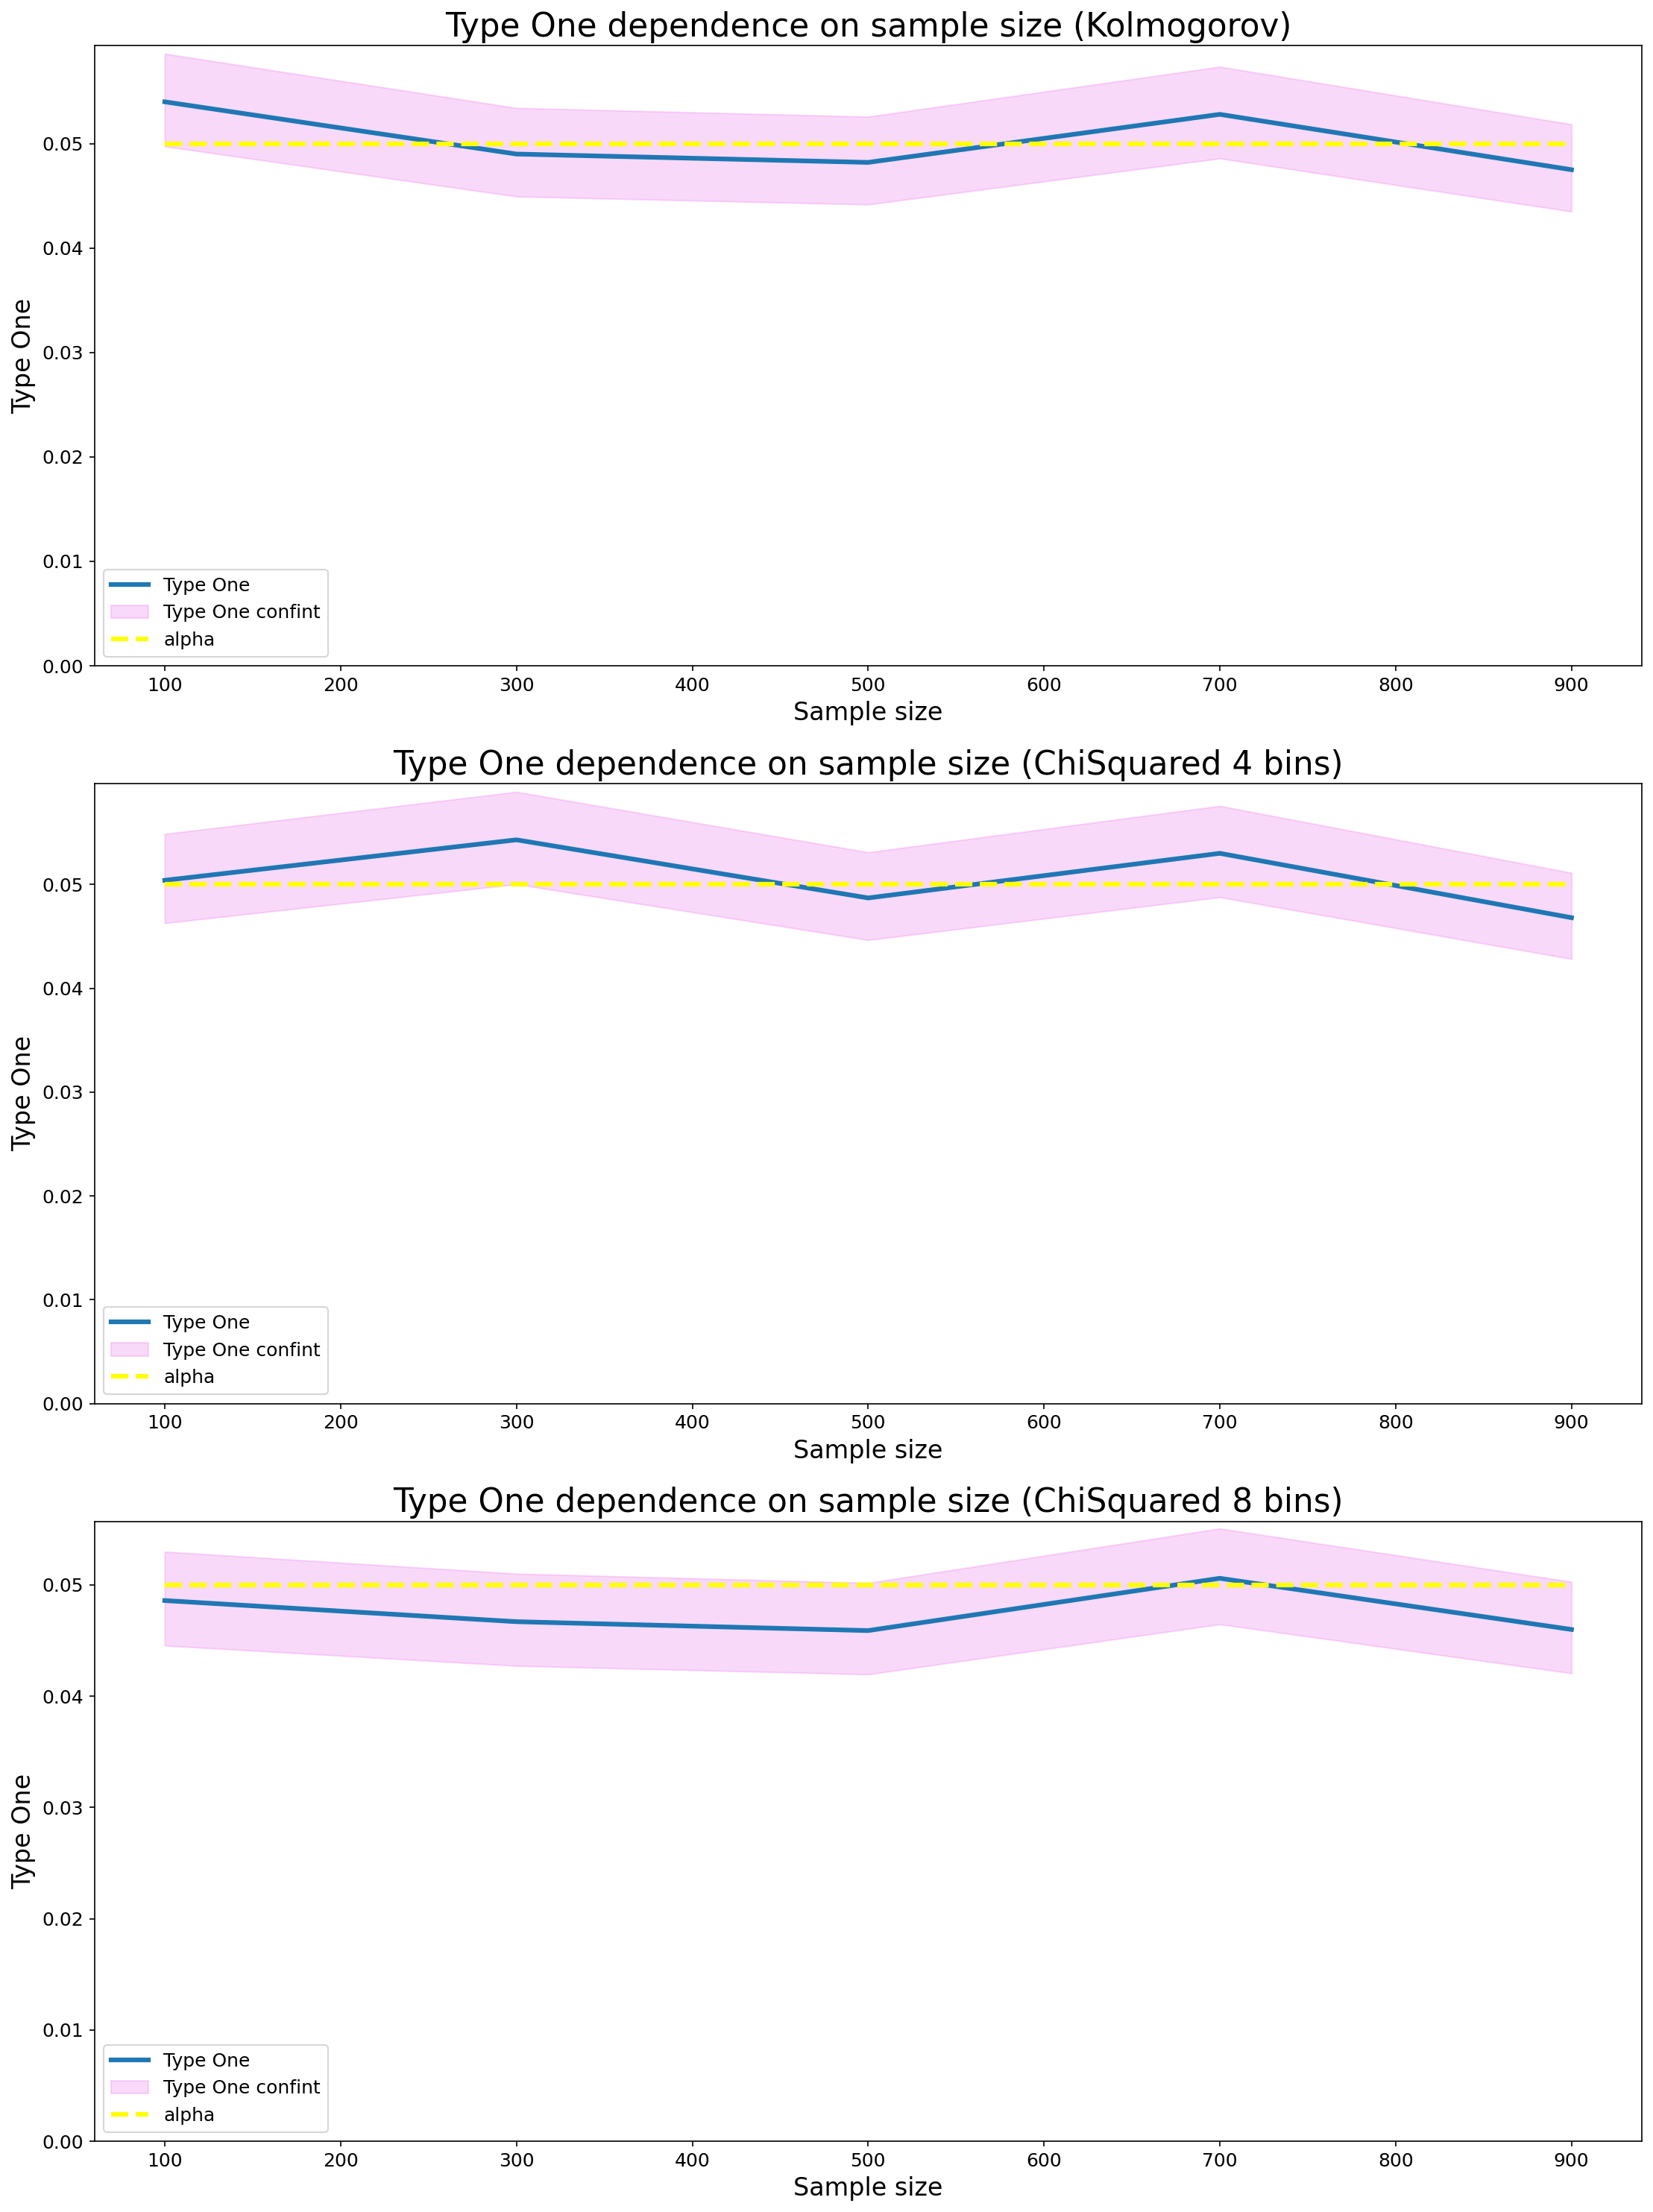

In [ ]:
# Рисуем 
# Видно, что для всех критериев уровень значимости alpha=0.05 
# лежит в доверительном интервале, то есть, критерии корректны

plt.figure(figsize=(15, 20))

plt.subplot(3, 1, 1)

plt.plot([elem[0] for elem in Komogorov_typeOne], 
            [elem[1].type_one for elem in Komogorov_typeOne], linewidth=3.0, label='Type One')
plt.fill_between([elem[0] for elem in Komogorov_typeOne], 
                    [elem[1].ci_left for elem in Komogorov_typeOne], 
                    [elem[1].ci_right for elem in Komogorov_typeOne], 
                    color = 'violet', alpha = 0.3, label='Type One confint')
plt.plot([elem[0] for elem in Komogorov_typeOne], np.array([0.05]*len(Komogorov_typeOne)),
            color = 'yellow', linestyle = 'dashed', 
            linewidth=3.0, label='alpha')

plt.legend()
plt.title("Type One dependence on sample size (Kolmogorov)")
plt.xlabel("Sample size")
plt.ylabel("Type One")
plt.ylim(bottom=0)

plt.subplot(3, 1, 2)

plt.plot([elem[0] for elem in ChiSquared4_typeOne], 
            [elem[1].type_one for elem in ChiSquared4_typeOne], linewidth=3.0, label='Type One')
plt.fill_between([elem[0] for elem in ChiSquared4_typeOne], 
                    [elem[1].ci_left for elem in ChiSquared4_typeOne], 
                    [elem[1].ci_right for elem in ChiSquared4_typeOne], 
                    color = 'violet', alpha = 0.3, label='Type One confint')
plt.plot([elem[0] for elem in ChiSquared4_typeOne], np.array([0.05]*len(ChiSquared4_typeOne)),
            color = 'yellow', linestyle = 'dashed', 
            linewidth=3.0, label='alpha')

plt.legend()
plt.title("Type One dependence on sample size (ChiSquared 4 bins)")
plt.xlabel("Sample size")
plt.ylabel("Type One")
plt.ylim(bottom=0)

plt.subplot(3, 1, 3)

plt.plot([elem[0] for elem in ChiSquared8_typeOne], 
            [elem[1].type_one for elem in ChiSquared8_typeOne], linewidth=3.0, label='Type One')
plt.fill_between([elem[0] for elem in ChiSquared8_typeOne], 
                    [elem[1].ci_left for elem in ChiSquared8_typeOne], 
                    [elem[1].ci_right for elem in ChiSquared8_typeOne], 
                    color = 'violet', alpha = 0.3, label='Type One confint')
plt.plot([elem[0] for elem in ChiSquared8_typeOne], np.array([0.05]*len(ChiSquared8_typeOne)),
            color = 'yellow', linestyle = 'dashed', 
            linewidth=3.0, label='alpha')

plt.legend()
plt.title("Type One dependence on sample size (ChiSquared 8 bins)")
plt.xlabel("Sample size")
plt.ylabel("Type One")
plt.ylim(bottom=0)

plt.tight_layout()

In [31]:
# Сдвигаем распределение с смотрим на мощность 

Kolmogorov_Power = []
ChiSquared4_Power = []
ChiSquared8_Power = []

# перебираем размер выборки n
for i in tqdm(np.arange(100, 1000, 200, dtype = int)):  
    mmk_res_ks = run_monte_carlo_Kolmogorov(sample_size = i, mu = 0.2, 
                                                     var = 1,
                                                     alpha = 0.05,
                                                     n_iter = 10000)
    Kolmogorov_Power.append([i, mmk_res_ks])
    
    mmk_res_chi_sq_4_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0.2,
                                                            var = 1,
                                                            n_bins = 4,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared4_Power.append([i, mmk_res_chi_sq_4_bins])
    
    mmk_res_chi_sq_8_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0.2,
                                                            var = 1,
                                                            n_bins = 8,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared8_Power.append([i, mmk_res_chi_sq_8_bins])

100%|██████████| 5/5 [00:57<00:00, 11.41s/it]


(0.0, 1.0386865245513797)

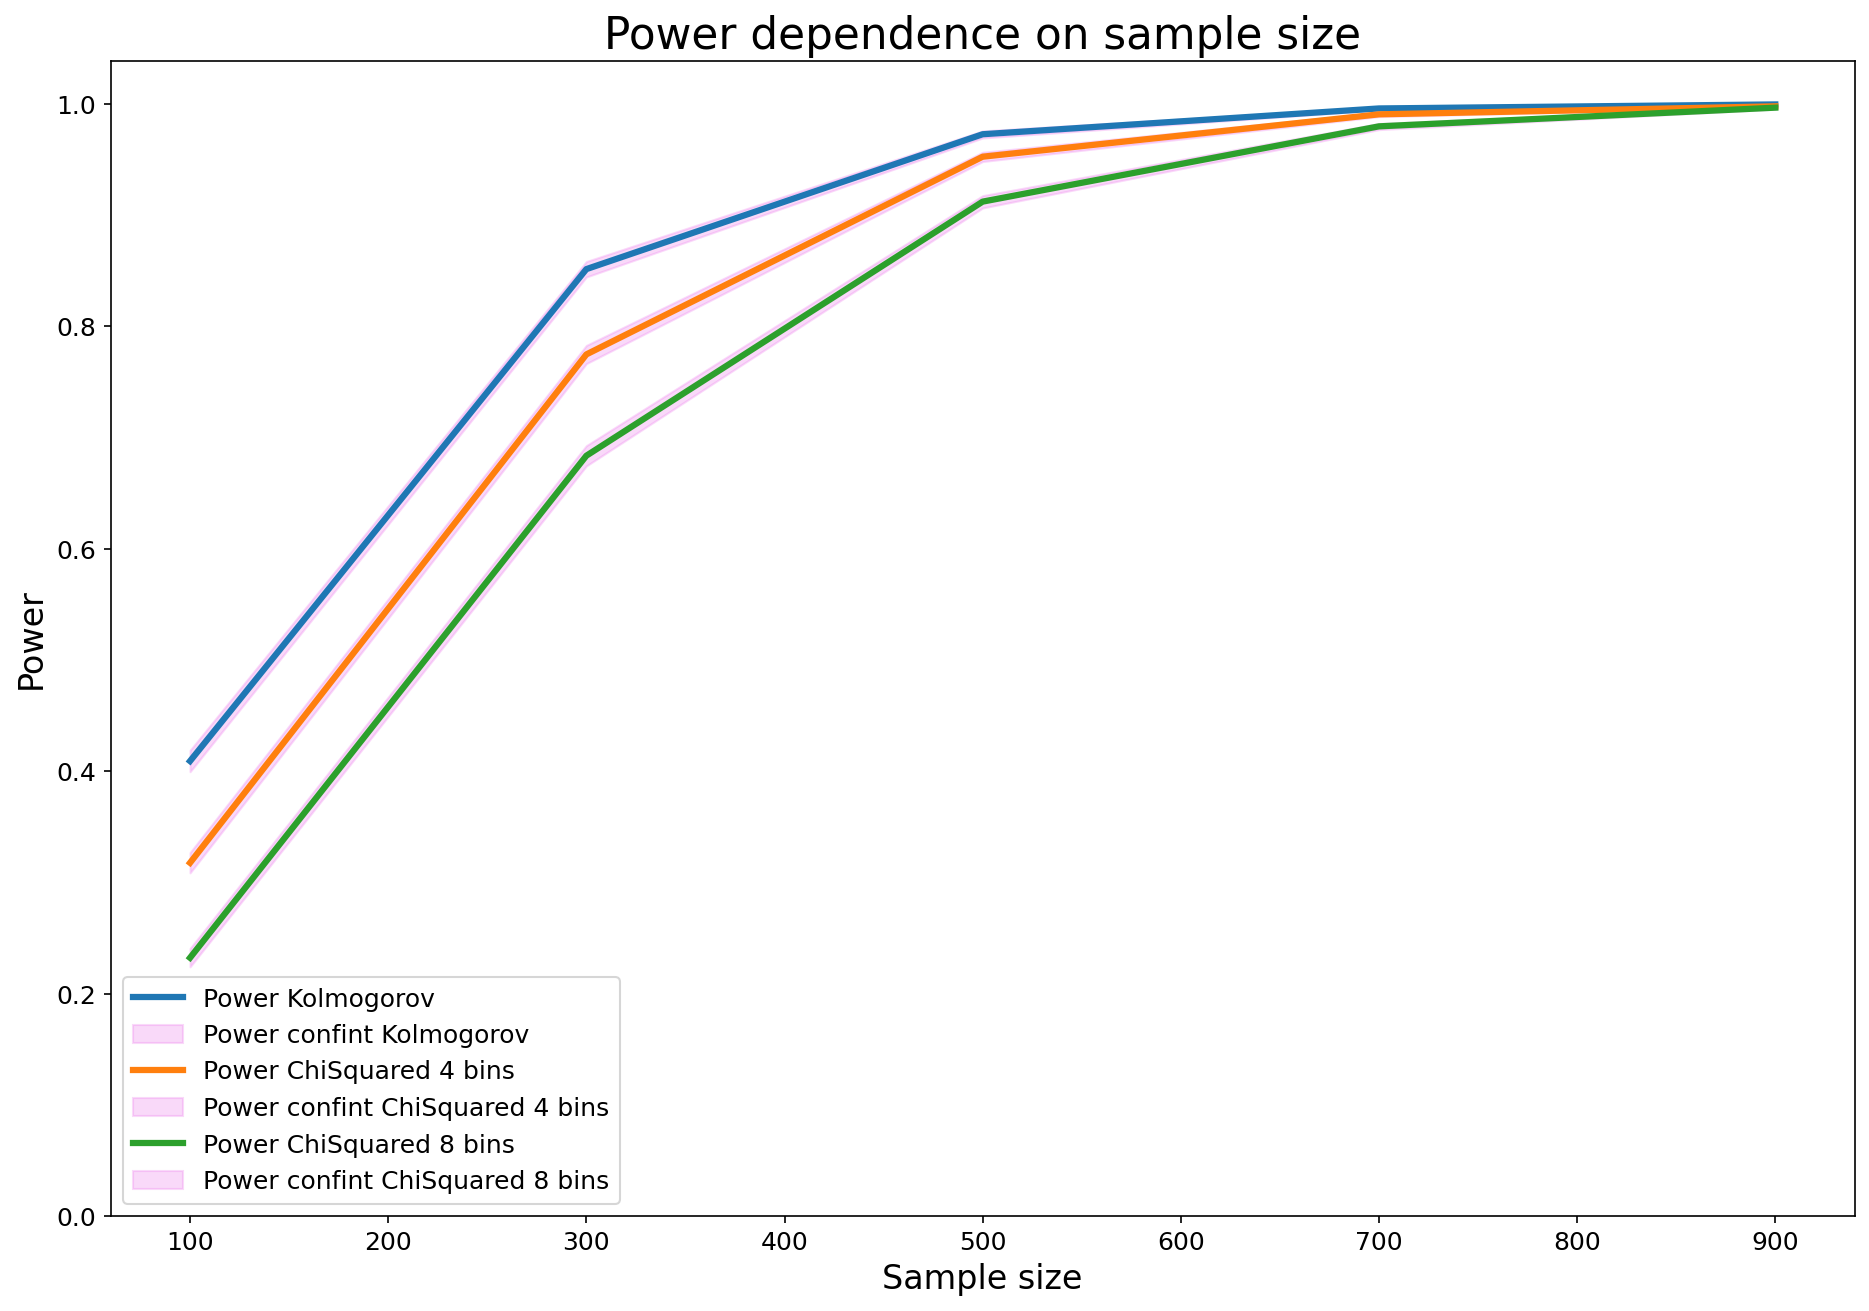

In [32]:
plt.figure(figsize=(15, 10))

plt.plot([elem[0] for elem in Kolmogorov_Power], 
            [elem[1].type_one for elem in Kolmogorov_Power], linewidth=3.0, label='Power Kolmogorov')
plt.fill_between([elem[0] for elem in Kolmogorov_Power], 
                    [elem[1].ci_left for elem in Kolmogorov_Power], 
                    [elem[1].ci_right for elem in Kolmogorov_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint Kolmogorov')

plt.plot([elem[0] for elem in ChiSquared4_Power], 
            [elem[1].type_one for elem in ChiSquared4_Power], linewidth=3.0, label='Power ChiSquared 4 bins')
plt.fill_between([elem[0] for elem in ChiSquared4_Power], 
                    [elem[1].ci_left for elem in ChiSquared4_Power], 
                    [elem[1].ci_right for elem in ChiSquared4_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint ChiSquared 4 bins')

plt.plot([elem[0] for elem in ChiSquared8_Power], 
            [elem[1].type_one for elem in ChiSquared8_Power], linewidth=3.0, label='Power ChiSquared 8 bins')
plt.fill_between([elem[0] for elem in ChiSquared8_Power], 
                    [elem[1].ci_left for elem in ChiSquared8_Power], 
                    [elem[1].ci_right for elem in ChiSquared8_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint ChiSquared 8 bins')

plt.legend()
plt.title("Power dependence on sample size")
plt.xlabel("Sample size")
plt.ylabel("Power")
plt.ylim(bottom=0)

> Вывод: для сдвига распределения мощность критерия Колмогорова > Хи-квадрат с 4 ячейками > Хи-квадрат с 8 ячейками

In [33]:
# Меняем дисперсию 

# Сдвигаем распределение с смотрим на мощность 

Kolmogorov_Power = []
ChiSquared4_Power = []
ChiSquared8_Power = []

# перебираем размер выборки n
for i in tqdm(np.arange(100, 1000, 200, dtype = int)):  
    mmk_res_ks = run_monte_carlo_Kolmogorov(sample_size = i, mu = 0, 
                                                     var = 1.1,
                                                     alpha = 0.05,
                                                     n_iter = 10000)
    Kolmogorov_Power.append([i, mmk_res_ks])
    
    mmk_res_chi_sq_4_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0,
                                                            var = 1.1,
                                                            n_bins = 4,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared4_Power.append([i, mmk_res_chi_sq_4_bins])
    
    mmk_res_chi_sq_8_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0,
                                                            var = 1.1,
                                                            n_bins = 8,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared8_Power.append([i, mmk_res_chi_sq_8_bins])

100%|██████████| 5/5 [00:49<00:00,  9.91s/it]


(0.0, 0.6643591893856539)

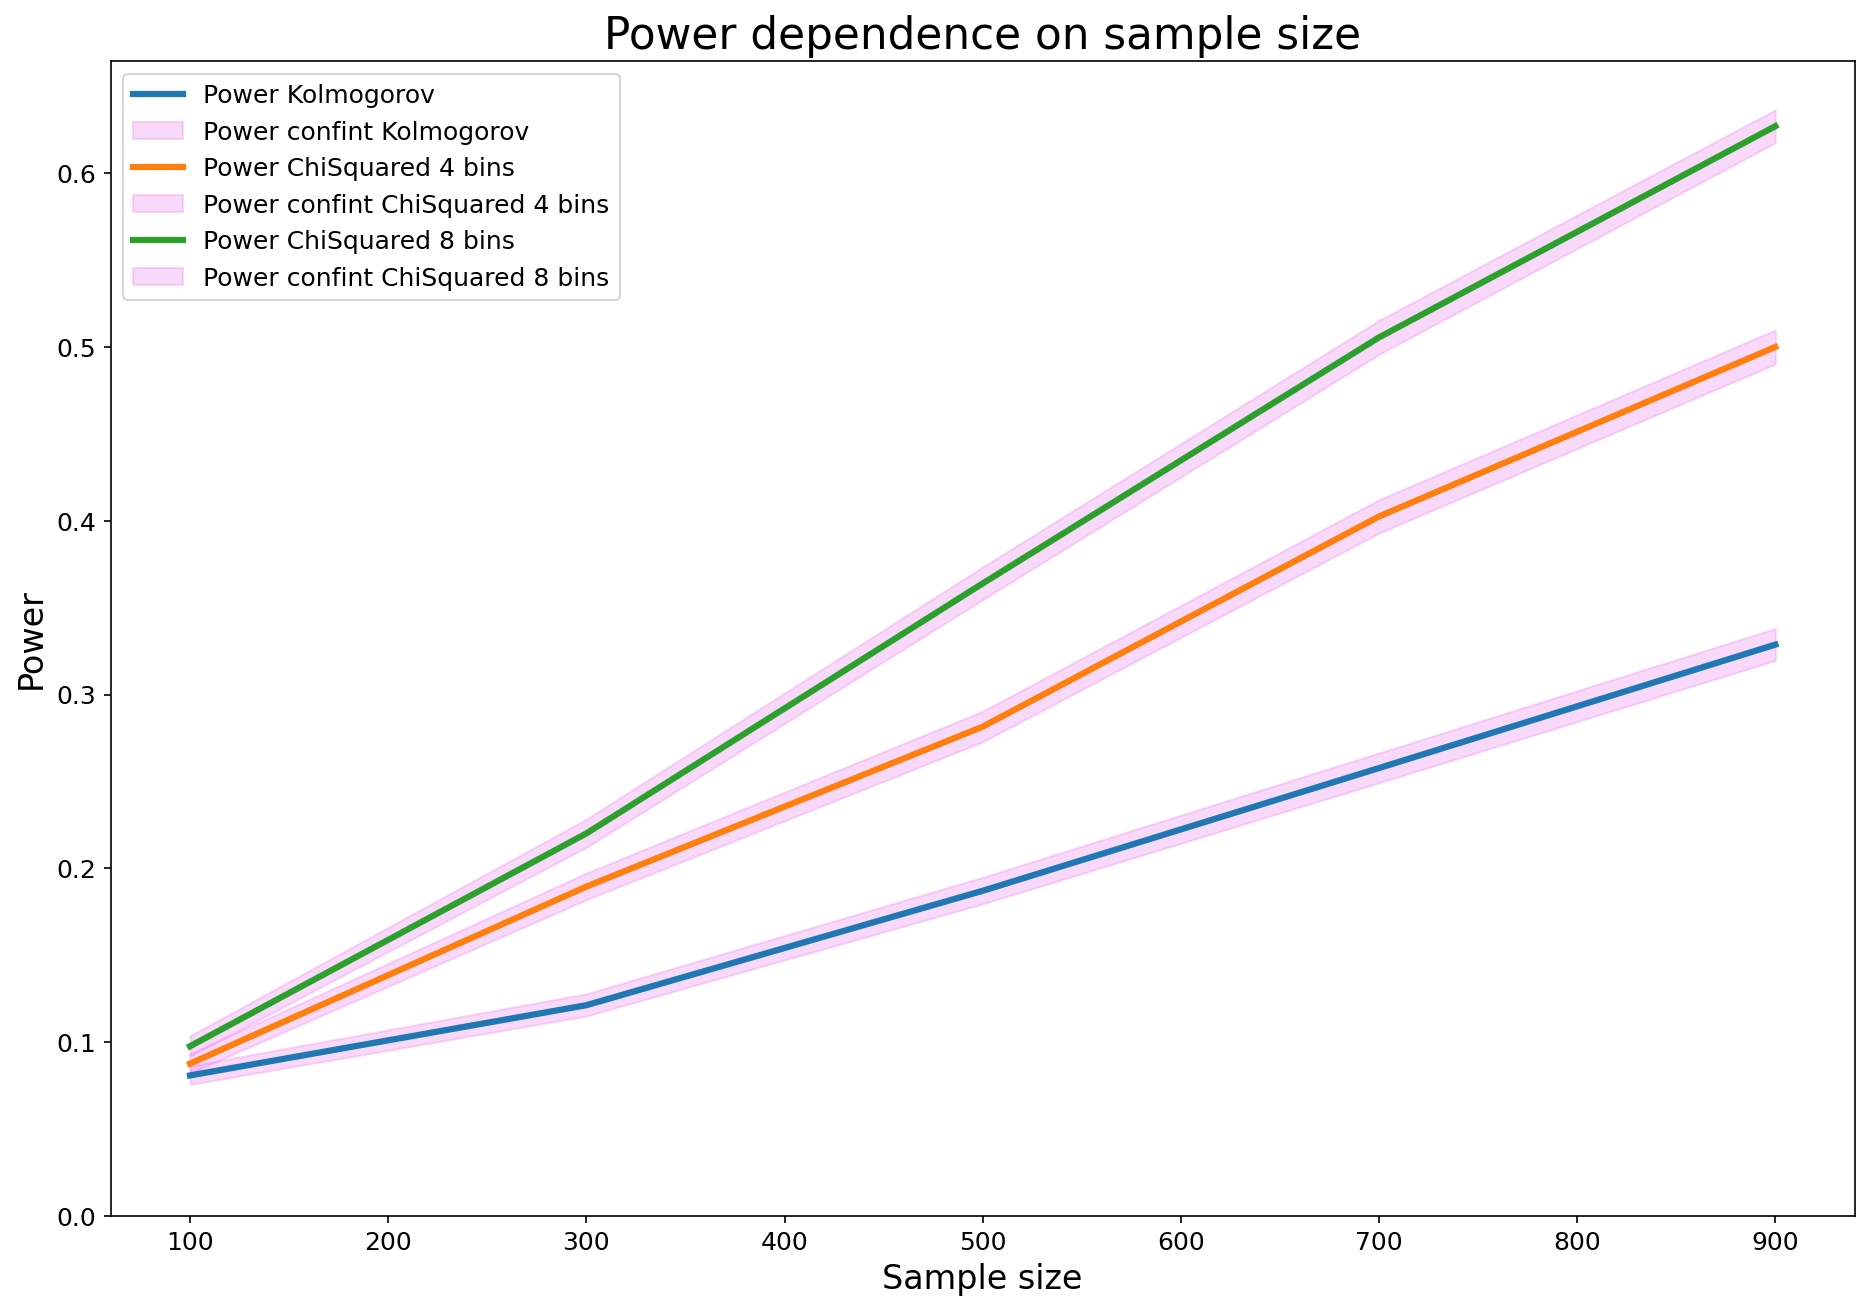

In [34]:
plt.figure(figsize=(15, 10))

plt.plot([elem[0] for elem in Kolmogorov_Power], 
            [elem[1].type_one for elem in Kolmogorov_Power], linewidth=3.0, label='Power Kolmogorov')
plt.fill_between([elem[0] for elem in Kolmogorov_Power], 
                    [elem[1].ci_left for elem in Kolmogorov_Power], 
                    [elem[1].ci_right for elem in Kolmogorov_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint Kolmogorov')

plt.plot([elem[0] for elem in ChiSquared4_Power], 
            [elem[1].type_one for elem in ChiSquared4_Power], linewidth=3.0, label='Power ChiSquared 4 bins')
plt.fill_between([elem[0] for elem in ChiSquared4_Power], 
                    [elem[1].ci_left for elem in ChiSquared4_Power], 
                    [elem[1].ci_right for elem in ChiSquared4_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint ChiSquared 4 bins')

plt.plot([elem[0] for elem in ChiSquared8_Power], 
            [elem[1].type_one for elem in ChiSquared8_Power], linewidth=3.0, label='Power ChiSquared 8 bins')
plt.fill_between([elem[0] for elem in ChiSquared8_Power], 
                    [elem[1].ci_left for elem in ChiSquared8_Power], 
                    [elem[1].ci_right for elem in ChiSquared8_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint ChiSquared 8 bins')

plt.legend()
plt.title("Power dependence on sample size")
plt.xlabel("Sample size")
plt.ylabel("Power")
plt.ylim(bottom=0)

> Вывод: для изменения дисперсии распределения мощность критерия Хи-квадрат с 8 ячейками > Хи-квадрат с 4 ячейками > Колмогорова

In [35]:
# Делаем сдвиг и меняем дисперсию

Kolmogorov_Power = []
ChiSquared4_Power = []
ChiSquared8_Power = []

# перебираем размер выборки n
for i in tqdm(np.arange(100, 1000, 200, dtype = int)):  
    mmk_res_ks = run_monte_carlo_Kolmogorov(sample_size = i, mu = 0.2, 
                                                     var = 1.1,
                                                     alpha = 0.05,
                                                     n_iter = 10000)
    Kolmogorov_Power.append([i, mmk_res_ks])
    
    mmk_res_chi_sq_4_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0.2,
                                                            var = 1.1,
                                                            n_bins = 4,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared4_Power.append([i, mmk_res_chi_sq_4_bins])
    
    mmk_res_chi_sq_8_bins = run_monte_carlo_ChiSquared(sample_size = i,
                                                            mu = 0.2,
                                                            var = 1.1,
                                                            n_bins = 8,
                                                            alpha = 0.05,
                                                            n_iter = 10000)
    ChiSquared8_Power.append([i, mmk_res_chi_sq_8_bins])

100%|██████████| 5/5 [00:57<00:00, 11.59s/it]


(0.0, 1.0346027165839726)

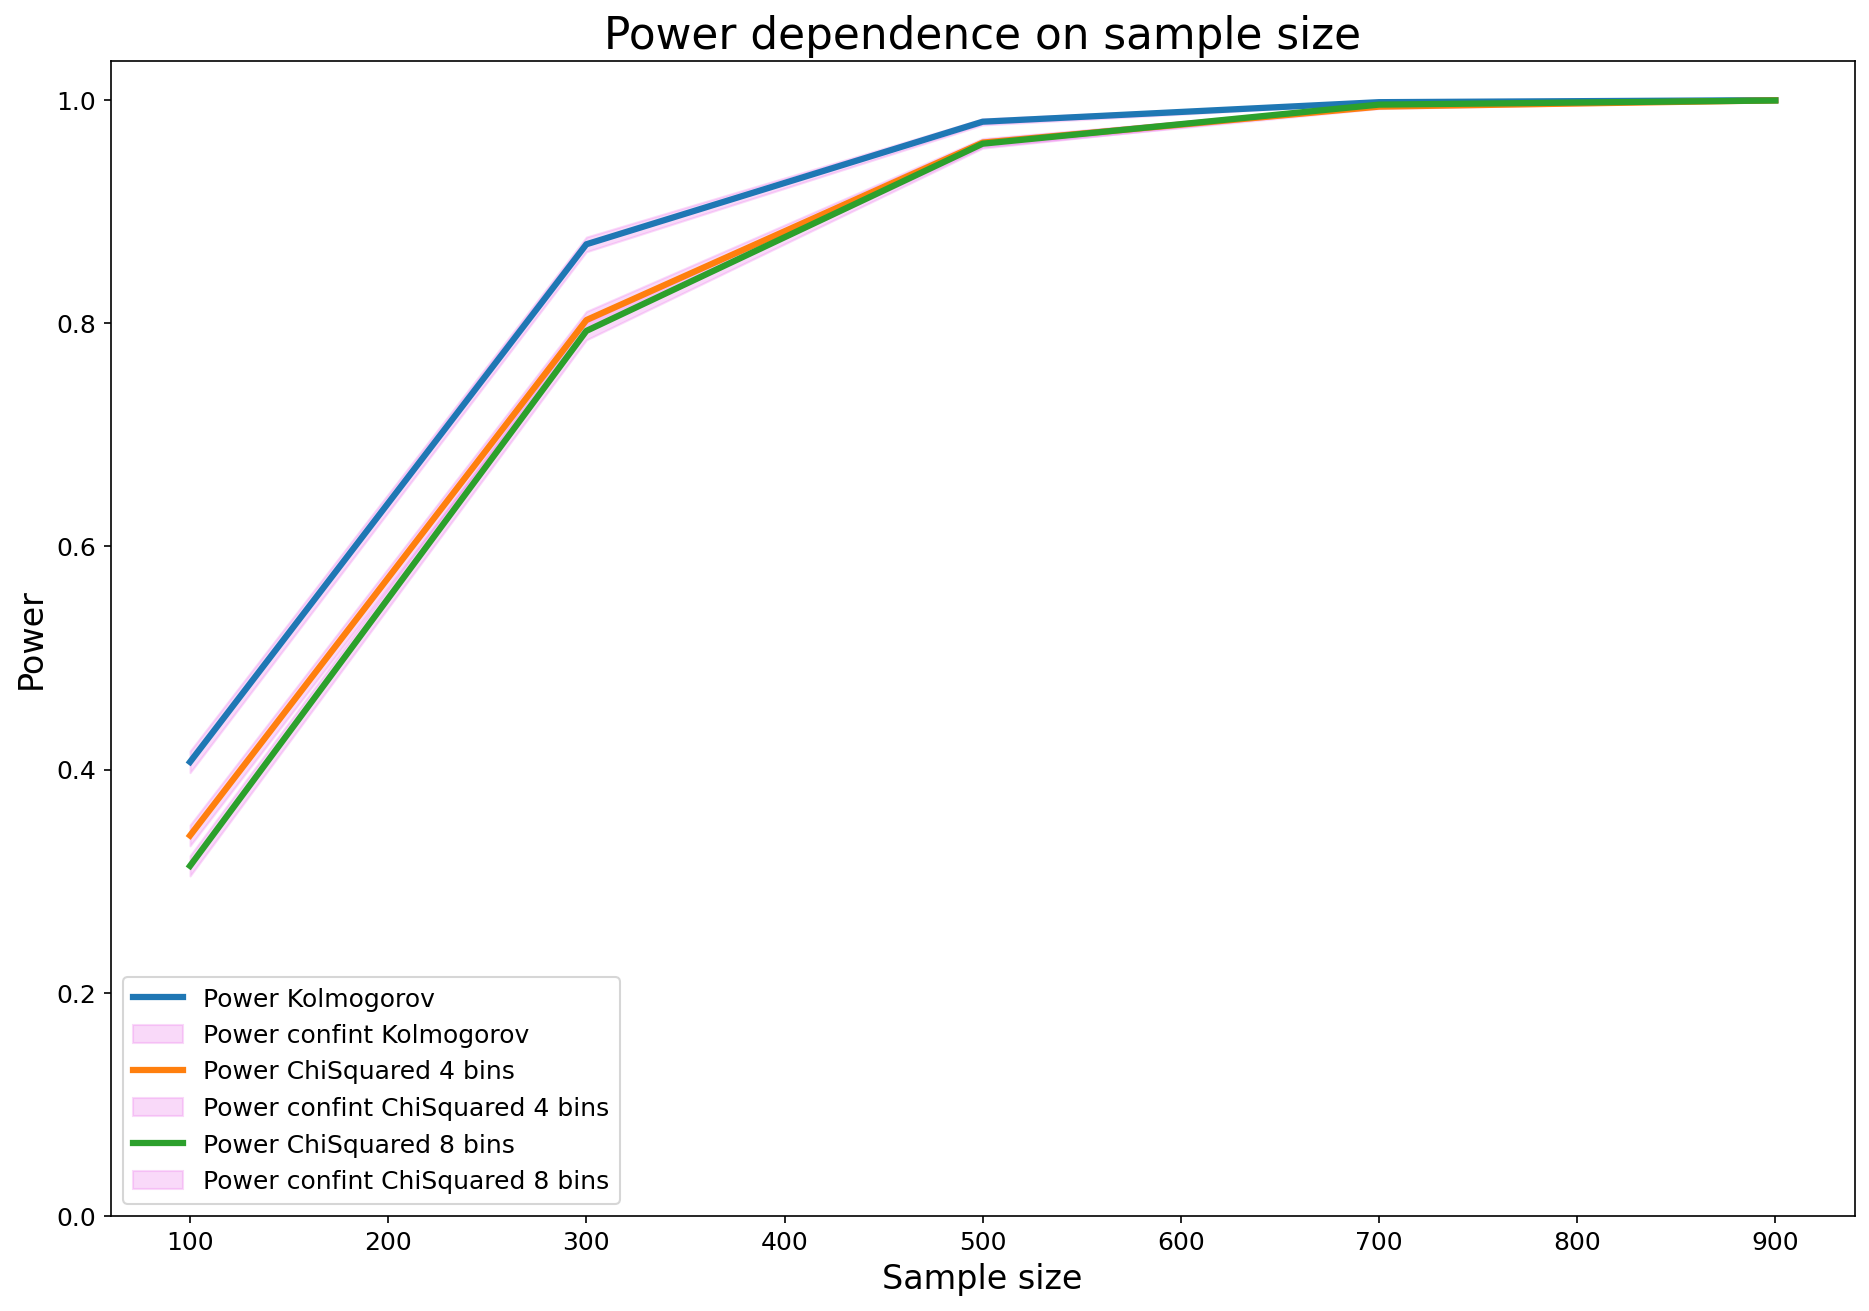

In [36]:
plt.figure(figsize=(15, 10))

plt.plot([elem[0] for elem in Kolmogorov_Power], 
            [elem[1].type_one for elem in Kolmogorov_Power], linewidth=3.0, label='Power Kolmogorov')
plt.fill_between([elem[0] for elem in Kolmogorov_Power], 
                    [elem[1].ci_left for elem in Kolmogorov_Power], 
                    [elem[1].ci_right for elem in Kolmogorov_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint Kolmogorov')

plt.plot([elem[0] for elem in ChiSquared4_Power], 
            [elem[1].type_one for elem in ChiSquared4_Power], linewidth=3.0, label='Power ChiSquared 4 bins')
plt.fill_between([elem[0] for elem in ChiSquared4_Power], 
                    [elem[1].ci_left for elem in ChiSquared4_Power], 
                    [elem[1].ci_right for elem in ChiSquared4_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint ChiSquared 4 bins')

plt.plot([elem[0] for elem in ChiSquared8_Power], 
            [elem[1].type_one for elem in ChiSquared8_Power], linewidth=3.0, label='Power ChiSquared 8 bins')
plt.fill_between([elem[0] for elem in ChiSquared8_Power], 
                    [elem[1].ci_left for elem in ChiSquared8_Power], 
                    [elem[1].ci_right for elem in ChiSquared8_Power], 
                    color = 'violet', alpha = 0.3, label='Power confint ChiSquared 8 bins')

plt.legend()
plt.title("Power dependence on sample size")
plt.xlabel("Sample size")
plt.ylabel("Power")
plt.ylim(bottom=0)